# 01 — Exploratory Data Analysis

Goals:
- Understand the raw JSON event structure
- Visualize the distribution of raw timing events across users
- Confirm class balance (legitimate vs impostor)
- Identify any users with missing or malformed sessions

In [6]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RAW_DATA_PATH = '../data/raw_kmt_dataset'

# Load one file to inspect the structure
sample_file = os.path.join(RAW_DATA_PATH, 'raw_kmt_user_0001.json')

with open(sample_file, 'r') as f:
    sample = json.load(f)

# Confirmed structure:
# sample['details']          — card metadata, not used in modeling
# sample['true_data']        — dict with keys test_1 through test_10 (legitimate sessions)
# sample['false_data']       — dict with keys test_1 through test_10 (impostor sessions)
# Each session has:
#   session['key_events']    — list of keyboard events
#   session['mouse_events']  — list of mouse events

print("Structure confirmed.")
print(f"Legitimate sessions: {list(sample['true_data'].keys())}")
print(f"Impostor sessions: {list(sample['false_data'].keys())}")

Structure confirmed.
Legitimate sessions: ['test_1', 'test_2', 'test_3', 'test_4', 'test_5', 'test_6', 'test_7', 'test_8', 'test_9', 'test_10']
Impostor sessions: ['test_1', 'test_2', 'test_3', 'test_4', 'test_5', 'test_6', 'test_7', 'test_8', 'test_9', 'test_10']


## Raw Event Structure

### Key Events
Each key event has:
- `Key` — which key was pressed (e.g. "shift", "a", "1")
- `Event` — either "pressed" or "released"
- `Input Box` — which form field the event occurred in (Name, Card Number, CVC, Expiry)
- `Text Changed` — whether the keystroke changed the field content
- `Timestamp` — human readable datetime string
- `Epoch` — Unix timestamp in seconds (float) — this is what we use for timing calculations

### Mouse Events
Each mouse event has:
- `Event` — "movement", "pressed", or "released"
- `Coordinates` — [x, y] pixel position on screen
- `Timestamp` — human readable datetime string
- `Epoch` — Unix timestamp in seconds (float)
- `Movement ID` — sequential ID for movement events

### What we derive from these
- **Dwell time** — Epoch(released) - Epoch(pressed) for the same key
- **Flight time** — Epoch(pressed on key N) - Epoch(released on key N-1)
- **Mouse velocity** — distance between coordinates / time between movement events
- **Hover time** — time cursor spends over a field before clicking
- **Click dwell** — Epoch(mouse released) - Epoch(mouse pressed)

In [7]:
# Inspect raw event structure
first_session = sample['true_data']['test_1']

print("=== KEY EVENTS ===")
print(f"Number of key events: {len(first_session['key_events'])}")
print("\nFirst key event:")
print(json.dumps(first_session['key_events'][0], indent=2))

print("\n=== MOUSE EVENTS ===")
print(f"Number of mouse events: {len(first_session['mouse_events'])}")
print("\nFirst mouse event:")
print(json.dumps(first_session['mouse_events'][0], indent=2))

=== KEY EVENTS ===
Number of key events: 118

First key event:
{
  "Key": "shift",
  "Event": "pressed",
  "Input Box": "Name",
  "Text Changed": true,
  "Timestamp": "2022-02-06 18:57:09.981740",
  "Epoch": "1644173829.9817405"
}

=== MOUSE EVENTS ===
Number of mouse events: 107

First mouse event:
{
  "Event": "movement",
  "Coordinates": [
    30.0,
    581.0
  ],
  "Timestamp": "2022-02-06 18:57:07.568143",
  "Epoch": "1644173827.5681436",
  "Movement ID": 1
}


In [8]:
# Load all 88 users into a summary dataframe
records = []

for filename in sorted(os.listdir(RAW_DATA_PATH)):
    if not filename.endswith('.json'):
        continue
    
    user_id = filename.replace('raw_kmt_user_', '').replace('.json', '')
    filepath = os.path.join(RAW_DATA_PATH, filename)
    
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    for label, sessions in [('legitimate', data['true_data']), ('impostor', data['false_data'])]:
        for session_id, session in sessions.items():
            key_count = len(session.get('key_events', []))
            mouse_count = len(session.get('mouse_events', []))
            
            records.append({
                'user_id': user_id,
                'session_id': session_id,
                'label': label,
                'key_event_count': key_count,
                'mouse_event_count': mouse_count
            })

df = pd.DataFrame(records)

print(f"Total sessions loaded: {len(df)}")
print(f"Unique users: {df['user_id'].nunique()}")
print(f"\nEvent counts summary:")
print(df[['key_event_count', 'mouse_event_count']].describe().round(2))

Total sessions loaded: 1760
Unique users: 88

Event counts summary:
       key_event_count  mouse_event_count
count          1760.00            1760.00
mean             98.05             402.70
std              31.82             341.93
min              20.00              77.00
25%              84.00             227.75
50%              90.00             329.00
75%             100.00             459.25
max             625.00            4899.00


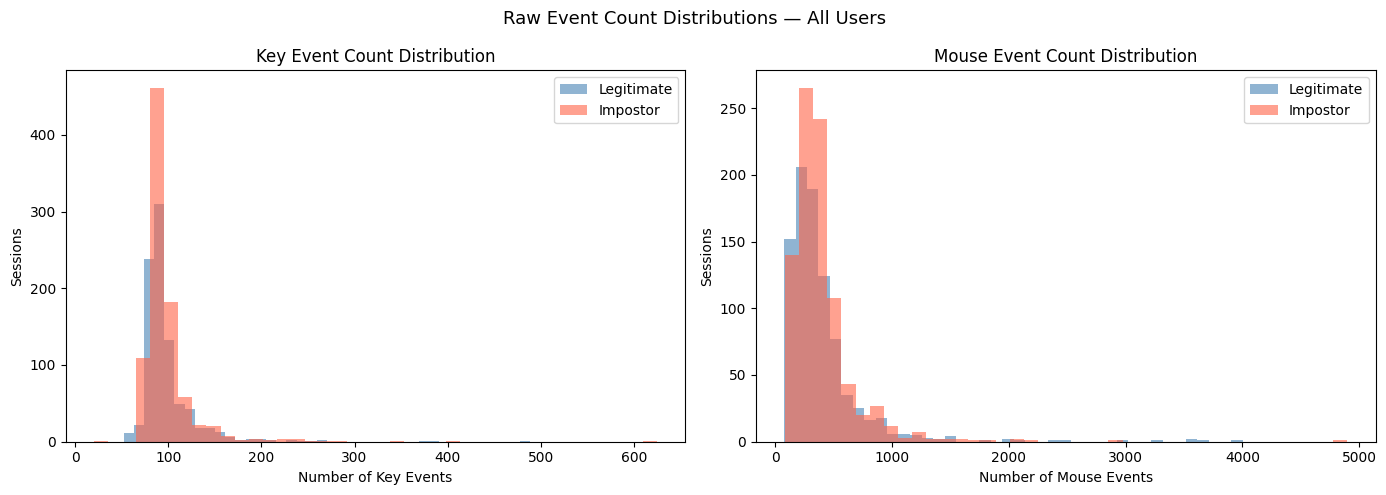


Mean key events by label:
label
impostor      98.05
legitimate    98.05
Name: key_event_count, dtype: float64

Mean mouse events by label:
label
impostor      404.92
legitimate    400.47
Name: mouse_event_count, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Key event count distribution
axes[0].hist(df[df['label'] == 'legitimate']['key_event_count'], 
             bins=40, alpha=0.6, label='Legitimate', color='steelblue')
axes[0].hist(df[df['label'] == 'impostor']['key_event_count'], 
             bins=40, alpha=0.6, label='Impostor', color='tomato')
axes[0].set_title('Key Event Count Distribution')
axes[0].set_xlabel('Number of Key Events')
axes[0].set_ylabel('Sessions')
axes[0].legend()

# Mouse event count distribution
axes[1].hist(df[df['label'] == 'legitimate']['mouse_event_count'], 
             bins=40, alpha=0.6, label='Legitimate', color='steelblue')
axes[1].hist(df[df['label'] == 'impostor']['mouse_event_count'], 
             bins=40, alpha=0.6, label='Impostor', color='tomato')
axes[1].set_title('Mouse Event Count Distribution')
axes[1].set_xlabel('Number of Mouse Events')
axes[1].set_ylabel('Sessions')
axes[1].legend()

plt.suptitle('Raw Event Count Distributions — All Users', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/01_event_count_distributions.png', dpi=150)
plt.show()

print("\nMean key events by label:")
print(df.groupby('label')['key_event_count'].mean().round(2))
print("\nMean mouse events by label:")
print(df.groupby('label')['mouse_event_count'].mean().round(2))

In [10]:
# Outlier investigation
# Identify outlier sessions
key_outliers = df[df['key_event_count'] > 200].sort_values('key_event_count', ascending=False)
mouse_outliers = df[df['mouse_event_count'] > 1500].sort_values('mouse_event_count', ascending=False)

print("=== KEY EVENT OUTLIERS (>200 events) ===")
print(key_outliers[['user_id', 'session_id', 'label', 'key_event_count']].to_string(index=False))

print("\n=== MOUSE EVENT OUTLIERS (>1500 events) ===")
print(mouse_outliers[['user_id', 'session_id', 'label', 'mouse_event_count']].to_string(index=False))

=== KEY EVENT OUTLIERS (>200 events) ===
user_id session_id      label  key_event_count
   0078     test_9   impostor              625
   0066     test_9 legitimate              489
   0027     test_8   impostor              412
   0066     test_5 legitimate              382
   0049     test_3 legitimate              370
   0084     test_7   impostor              340
   0076     test_7   impostor              283
   0048     test_4   impostor              272
   0077     test_2 legitimate              268
   0085     test_3 legitimate              267
   0048     test_8 legitimate              249
   0080     test_8   impostor              248
   0078     test_7   impostor              246
   0078     test_1 legitimate              244
   0078     test_8   impostor              244
   0083     test_7   impostor              238
   0081     test_3 legitimate              233
   0086     test_5 legitimate              229
   0012     test_4   impostor              224
   0055     test_4 

In [15]:
# Structural integrity and missingness analysis — all 88 users
issues = []

for filename in sorted(os.listdir(RAW_DATA_PATH)):
    if not filename.endswith('.json'):
        continue

    user_id = filename.replace('raw_kmt_user_', '').replace('.json', '')
    
    with open(os.path.join(RAW_DATA_PATH, filename), 'r') as f:
        data = json.load(f)

    for label, sessions in [('legitimate', data['true_data']), ('impostor', data['false_data'])]:
        for session_id, session in sessions.items():

            key_events = session.get('key_events', [])
            mouse_events = session.get('mouse_events', [])

            # Empty sessions
            if len(key_events) == 0:
                issues.append({'user_id': user_id, 'session_id': session_id,
                                'label': label, 'issue': 'empty_key_events'})
            if len(mouse_events) == 0:
                issues.append({'user_id': user_id, 'session_id': session_id,
                                'label': label, 'issue': 'empty_mouse_events'})

            # Malformed records — missing Event field
            for i, e in enumerate(key_events):
                if 'Event' not in e or 'Epoch' not in e:
                    issues.append({'user_id': user_id, 'session_id': session_id,
                                    'label': label, 'issue': f'malformed_key_event_at_index_{i}'})

            for i, e in enumerate(mouse_events):
                if 'Event' not in e or 'Epoch' not in e:
                    issues.append({'user_id': user_id, 'session_id': session_id,
                                    'label': label, 'issue': f'malformed_mouse_event_at_index_{i}'})

            # Out of order timestamps
            key_epochs = [float(e['Epoch']) for e in key_events if 'Epoch' in e]
            if key_epochs != sorted(key_epochs):
                issues.append({'user_id': user_id, 'session_id': session_id,
                                'label': label, 'issue': 'out_of_order_key_epochs'})

            mouse_epochs = [float(e['Epoch']) for e in mouse_events if 'Epoch' in e]
            if mouse_epochs != sorted(mouse_epochs):
                issues.append({'user_id': user_id, 'session_id': session_id,
                                'label': label, 'issue': 'out_of_order_mouse_epochs'})

issues_df = pd.DataFrame(issues)

if issues_df.empty:
    print("No structural issues found.")
else:
    print(f"Total issues found: {len(issues_df)}")
    print(f"\nIssues by type:")
    print(issues_df['issue'].value_counts())
    print(f"\nUsers affected: {issues_df['user_id'].nunique()}")

Total issues found: 1760

Issues by type:
issue
malformed_mouse_event_at_index_321    11
malformed_mouse_event_at_index_216    10
malformed_mouse_event_at_index_212     9
malformed_mouse_event_at_index_241     9
malformed_mouse_event_at_index_335     9
                                      ..
malformed_mouse_event_at_index_855     1
malformed_mouse_event_at_index_912     1
malformed_mouse_event_at_index_538     1
malformed_mouse_event_at_index_83      1
malformed_mouse_event_at_index_76      1
Name: count, Length: 663, dtype: int64

Users affected: 88


In [16]:
# Understand the malformed records better
malformed_records = []

for filename in sorted(os.listdir(RAW_DATA_PATH)):
    if not filename.endswith('.json'):
        continue

    user_id = filename.replace('raw_kmt_user_', '').replace('.json', '')

    with open(os.path.join(RAW_DATA_PATH, filename), 'r') as f:
        data = json.load(f)

    for label, sessions in [('legitimate', data['true_data']), ('impostor', data['false_data'])]:
        for session_id, session in sessions.items():
            for e in session['mouse_events']:
                if 'Event' not in e:
                    malformed_records.append({
                        'user_id': user_id,
                        'session_id': session_id,
                        'label': label,
                        'record': str(e)
                    })

malformed_df = pd.DataFrame(malformed_records)

print(f"Total malformed mouse records: {len(malformed_df)}")
print(f"\nUnique malformed record types:")
print(malformed_df['record'].value_counts().head(20))

Total malformed mouse records: 1760

Unique malformed record types:
record
{'false_enters': 0}     1544
{'false_enters': 1}      140
{'false_enters': 2}       29
{'false_enters': 3}       24
{'false_enters': 4}        5
{'false_enters': 6}        5
{'false_enters': 5}        4
{'false_enters': 18}       2
{'false_enters': 8}        2
{'false_enters': 25}       1
{'false_enters': 22}       1
{'false_enters': 9}        1
{'false_enters': 35}       1
{'false_enters': 7}        1
Name: count, dtype: int64


In [17]:
# Extract false_enters and check if it differs by class
false_enters_records = []

for filename in sorted(os.listdir(RAW_DATA_PATH)):
    if not filename.endswith('.json'):
        continue

    user_id = filename.replace('raw_kmt_user_', '').replace('.json', '')

    with open(os.path.join(RAW_DATA_PATH, filename), 'r') as f:
        data = json.load(f)

    for label, sessions in [('legitimate', data['true_data']), ('impostor', data['false_data'])]:
        for session_id, session in sessions.items():
            false_enters = 0
            for e in session['mouse_events']:
                if 'false_enters' in e:
                    false_enters = e['false_enters']
            
            false_enters_records.append({
                'user_id': user_id,
                'session_id': session_id,
                'label': label,
                'false_enters': false_enters
            })

fe_df = pd.DataFrame(false_enters_records)

print("=== FALSE ENTERS BY CLASS ===")
print(fe_df.groupby('label')['false_enters'].describe().round(3))

print("\nSessions with any errors:")
print(fe_df[fe_df['false_enters'] > 0].groupby('label').size())

print("\nMean false enters:")
print(fe_df.groupby('label')['false_enters'].mean().round(4))

=== FALSE ENTERS BY CLASS ===
            count   mean    std  min  25%  50%  75%   max
label                                                    
impostor    880.0  0.269  1.526  0.0  0.0  0.0  0.0  35.0
legitimate  880.0  0.288  1.466  0.0  0.0  0.0  0.0  25.0

Sessions with any errors:
label
impostor      105
legitimate    111
dtype: int64

Mean false enters:
label
impostor      0.2693
legitimate    0.2875
Name: false_enters, dtype: float64


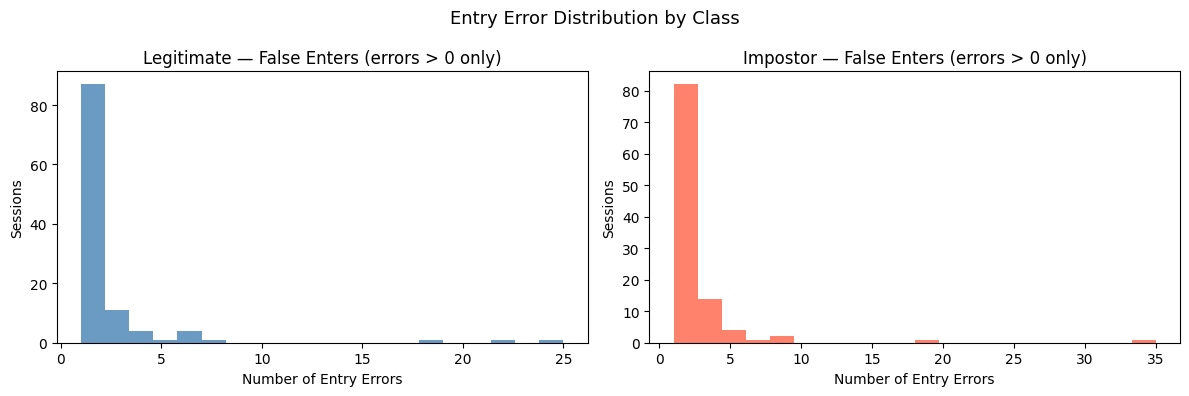


Sessions with zero errors: 1544 / 1760


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of false_enters by class
for ax, label, color in zip(axes, ['legitimate', 'impostor'], ['steelblue', 'tomato']):
    data = fe_df[fe_df['label'] == label]['false_enters']
    ax.hist(data[data > 0], bins=20, color=color, alpha=0.8)
    ax.set_title(f'{label.capitalize()} — False Enters (errors > 0 only)')
    ax.set_xlabel('Number of Entry Errors')
    ax.set_ylabel('Sessions')

plt.suptitle('Entry Error Distribution by Class', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/02_false_enters_distribution.png', dpi=150)
plt.show()

print(f"\nSessions with zero errors: {(fe_df['false_enters'] == 0).sum()} / {len(fe_df)}")

### Finding: false_enters

- Every session contains exactly one metadata record `{'false_enters': N}` 
  appended into the mouse events list — a bug in the data collection application
- 1,544 / 1,760 sessions (87.7%) had zero entry errors
- Mean errors: legitimate = 0.288, impostor = 0.269 — no meaningful difference
- `false_enters` will be extracted as a session-level feature but is not expected 
  to be discriminative between classes
- All mouse event parsers must filter out records missing the `Event` field

In [19]:
# Class balance across all 88 users
balance = df.groupby(['user_id', 'label']).size().unstack(fill_value=0)
balance.columns = ['impostor', 'legitimate']

print("=== OVERALL CLASS BALANCE ===")
print(df['label'].value_counts())
print(f"\nPerfectly balanced users (10 each): {(balance['impostor'] == 10).sum()}")
print(f"Users with fewer than 10 impostor sessions:   {(balance['impostor'] < 10).sum()}")
print(f"Users with fewer than 10 legitimate sessions: {(balance['legitimate'] < 10).sum()}")

# Flag any imbalanced users
imbalanced = balance[(balance['impostor'] != 10) | (balance['legitimate'] != 10)]
if imbalanced.empty:
    print("\nAll 88 users have exactly 10 sessions per class.")
else:
    print(f"\nImbalanced users:")
    print(imbalanced)

=== OVERALL CLASS BALANCE ===
label
legitimate    880
impostor      880
Name: count, dtype: int64

Perfectly balanced users (10 each): 88
Users with fewer than 10 impostor sessions:   0
Users with fewer than 10 legitimate sessions: 0

All 88 users have exactly 10 sessions per class.


### Finding: Class Balance

- Perfect 50/50 balance across all 88 users — 880 legitimate, 880 impostor
- Every user has exactly 10 sessions per class without exception
- No rebalancing techniques required (no SMOTE, no class weights)
- Evaluation metrics: since classes are balanced, accuracy is meaningful 
  but we will still prioritize FAR and FRR as they carry operational meaning

In [20]:
# Extract raw dwell and flight times across all users for distribution analysis
timing_records = []

for filename in sorted(os.listdir(RAW_DATA_PATH)):
    if not filename.endswith('.json'):
        continue

    user_id = filename.replace('raw_kmt_user_', '').replace('.json', '')

    with open(os.path.join(RAW_DATA_PATH, filename), 'r') as f:
        data = json.load(f)

    for label, sessions in [('legitimate', data['true_data']), ('impostor', data['false_data'])]:
        for session_id, session in sessions.items():

            # Filter clean key events only
            key_events = [e for e in session['key_events'] if 'Event' in e and 'Epoch' in e]

            pressed = {}
            dwell_times = []
            release_epochs = []

            for event in key_events:
                key = event['Key']
                epoch = float(event['Epoch'])
                action = event['Event']

                if action == 'pressed':
                    pressed[key] = epoch
                elif action == 'released' and key in pressed:
                    dwell = epoch - pressed[key]
                    if dwell >= 0:
                        dwell_times.append(dwell)
                    release_epochs.append(epoch)
                    del pressed[key]

            # Flight times from consecutive releases to next press
            press_epochs = sorted([float(e['Epoch']) for e in key_events if e['Event'] == 'pressed'])
            release_epochs = sorted(release_epochs)

            flight_times = []
            for i in range(min(len(release_epochs), len(press_epochs)) - 1):
                flight = press_epochs[i+1] - release_epochs[i]
                if 0 < flight < 2.0:  # cap at 2 seconds — longer gaps are pauses not transitions
                    flight_times.append(flight)

            timing_records.append({
                'user_id': user_id,
                'session_id': session_id,
                'label': label,
                'dwell_mean': np.mean(dwell_times) if dwell_times else np.nan,
                'dwell_std': np.std(dwell_times) if dwell_times else np.nan,
                'flight_mean': np.mean(flight_times) if flight_times else np.nan,
                'flight_std': np.std(flight_times) if flight_times else np.nan,
                'dwell_times': dwell_times,
                'flight_times': flight_times
            })

timing_df = pd.DataFrame(timing_records)

print(f"Sessions processed: {len(timing_df)}")
print(f"Sessions with NaN dwell: {timing_df['dwell_mean'].isna().sum()}")
print(f"Sessions with NaN flight: {timing_df['flight_mean'].isna().sum()}")
print(f"\nDwell time summary (seconds):")
print(timing_df.groupby('label')[['dwell_mean', 'dwell_std']].describe().round(4))

Sessions processed: 1760
Sessions with NaN dwell: 0
Sessions with NaN flight: 52

Dwell time summary (seconds):
           dwell_mean                                                          \
                count    mean     std     min     25%     50%     75%     max   
label                                                                           
impostor        880.0  0.1148  0.0255  0.0616  0.0969  0.1172  0.1299  0.2146   
legitimate      880.0  0.1162  0.0271  0.0659  0.0942  0.1173  0.1317  0.2131   

           dwell_std                                                          
               count    mean     std     min     25%     50%     75%     max  
label                                                                         
impostor       880.0  0.0444  0.0284  0.0097  0.0240  0.0338  0.0605  0.2697  
legitimate     880.0  0.0439  0.0287  0.0094  0.0244  0.0347  0.0573  0.2955  


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Population level — dwell mean
axes[0,0].hist(timing_df[timing_df['label']=='legitimate']['dwell_mean'], 
               bins=50, alpha=0.6, label='Legitimate', color='steelblue')
axes[0,0].hist(timing_df[timing_df['label']=='impostor']['dwell_mean'], 
               bins=50, alpha=0.6, label='Impostor', color='tomato')
axes[0,0].set_title('Population Level — Dwell Time Mean')
axes[0,0].set_xlabel('Seconds')
axes[0,0].legend()

# Population level — flight mean
axes[0,1].hist(timing_df[timing_df['label']=='legitimate']['flight_mean'].dropna(), 
               bins=50, alpha=0.6, label='Legitimate', color='steelblue')
axes[0,1].hist(timing_df[timing_df['label']=='impostor']['flight_mean'].dropna(), 
               bins=50, alpha=0.6, label='Impostor', color='tomato')
axes[0,1].set_title('Population Level — Flight Time Mean')
axes[0,1].set_xlabel('Seconds')
axes[0,1].legend()

# Per user level — pick 3 users and show their dwell distributions
sample_users = ['0001', '0010', '0025']
colors = ['steelblue', 'tomato']

for idx, user_id in enumerate(sample_users):
    ax = axes[1, idx] if idx < 2 else axes[1, 1]
    user_data = timing_df[timing_df['user_id'] == user_id]
    
    for label, color in zip(['legitimate', 'impostor'], colors):
        sessions = user_data[user_data['label'] == label]['dwell_times'].values
        all_dwells = [d for session in sessions for d in session]
        ax.hist(all_dwells, bins=30, alpha=0.6, label=label.capitalize(), color=color)
    
    ax.set_title(f'User {user_id} — Dwell Time Distribution')
    ax.set_xlabel('Seconds')
    ax.legend()

# Use last subplot for user 0025
user_data = timing_df[timing_df['user_id'] == '0025']
axes[1,1].cla()
for label, color in zip(['legitimate', 'impostor'], colors):
    sessions = user_data[user_data['label'] == label]['dwell_times'].values
    all_dwells = [d for session in sessions for d in session]
    axes[1,1].hist(all_dwells, bins=30, alpha=0.6, label=label.capitalize(), color=color)
axes[1,1].set_title('User 0025 — Dwell Time Distribution')
axes[1,1].set_xlabel('Seconds')
axes[1,1].legend()

plt.suptitle('Dwell Time: Population vs Per-User Separation', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/03_dwell_time_distributions.png', dpi=150)
plt.show()